# Empirical Bayes for Automatic Hyperparameter Tuning

When using `NormalRegressor` in a contextual bandit, you must specify two hyperparameters:

- **`alpha`** (prior precision): Controls how strongly the model regularizes its coefficients toward zero. Too high means the model is slow to learn; too low means it overfits early data.
- **`beta`** (noise precision): Controls how much the model trusts individual observations. Too high means updates are too aggressive; too low means the model learns too slowly.

In practice, these are rarely known upfront. Misspecified hyperparameters lead to poor exploration-exploitation tradeoffs: the bandit either over-explores (wasting pulls on suboptimal arms) or under-explores (locking in on a suboptimal arm too early).

`EmpiricalBayesNormalRegressor` solves this by automatically tuning `alpha` and `beta` via **evidence maximization** (MacKay's update rules). Each time the model is updated, it adjusts the hyperparameters to maximize the marginal likelihood of the observed data.

In this notebook, we demonstrate that:
1. A `NormalRegressor` with badly misspecified hyperparameters suffers high regret
2. An `EmpiricalBayesNormalRegressor` initialized with the **same bad hyperparameters** recovers and matches or beats a well-tuned baseline
3. Adding a **decay rate** enables the EB agent to **adapt to non-stationarity** — when the environment shifts, the EB + decay agent tracks the new optimal hyperparameters while stationary agents stay stuck with outdated estimates

## Setup: Linear Reward Oracle with Regime Shift

We simulate a contextual bandit where the expected reward for each arm is a linear function of user features. The oracle knows the true coefficients and noise level; the bandit agents do not.

To demonstrate the value of decay, we use a **two-regime data-generating process**:

- **Phase 1** (rounds 0–2499): Large coefficients, low noise (`sigma=0.5`). The optimal EB hyperparameters are low alpha (weak regularization) and high beta (trust data). Arm 0 is best on average.
- **Phase 2** (rounds 2500–4999): Smaller coefficients, higher noise (`sigma=1.0`). The optimal alpha is higher (more regularization) and optimal beta is lower. Arm 1 is now best.

This creates an environment where the stationary agents' converged hyperparameters and learned coefficients are wrong for the second phase, while the EB + decay agent can adapt.

We use a **shared model** (`LipschitzContextualAgent`) so that all arms contribute data to a single learner. This is essential for empirical Bayes — the hyperparameter updates need sufficient data from every observation, not just the 1-in-K observations that happen to land on a particular arm.

In [1]:
import numpy as np
from numpy.typing import NDArray

rng = np.random.default_rng(42)

# Phase 1: strong signal, low noise
TRUE_COEFS_1 = np.array(
    [
        [1.0, 0.5, -0.3, 0.2],  # arm 0: best on average
        [-0.5, 0.8, 0.1, -0.4],  # arm 1
        [0.3, -0.2, 0.6, 0.1],  # arm 2
        [0.0, 0.1, 0.1, 0.7],  # arm 3
    ]
)
TRUE_NOISE_STD_1 = 0.5  # beta_true = 4.0

# Phase 2: weaker signal, noisier — different optimal hyperparams
TRUE_COEFS_2 = np.array(
    [
        [0.0, 0.1, 0.1, -0.1],  # arm 0: was best, now weakest
        [0.3, 0.2, 0.3, 0.2],  # arm 1: now best (moderate, uniform)
        [-0.2, 0.1, -0.1, 0.1],  # arm 2
        [0.1, -0.1, 0.2, 0.1],  # arm 3
    ]
)
TRUE_NOISE_STD_2 = 1.0  # beta_true = 1.0

SHIFT_ROUND = 2500

N_ARMS = TRUE_COEFS_1.shape[0]
FEATURE_NAMES = ["intercept", "feature_1", "feature_2", "feature_3"]


class LinearRewardOracle:
    """Generates linear rewards with Gaussian noise."""

    def __init__(self, coefs: NDArray[np.float64], noise_std: float):
        self.coefs = coefs
        self.noise_std = noise_std
        self.context: NDArray[np.float64] = np.zeros(coefs.shape[1])

    def set_context(self, context: NDArray[np.float64]) -> None:
        self.context = context

    def expected_reward(self, arm_idx: int) -> float:
        return float(self.context @ self.coefs[arm_idx])

    def best_expected_reward(self) -> float:
        return float(np.max(self.context @ self.coefs.T))

    def generate_reward(self, arm_idx: int, rng: np.random.Generator) -> float:
        return self.expected_reward(arm_idx) + rng.normal(0, self.noise_std)


oracle = LinearRewardOracle(TRUE_COEFS_1, TRUE_NOISE_STD_1)

## Defining the Arms and Agents

We compare four agents, all using Thompson Sampling with a **shared model** (`LipschitzContextualAgent`). The arm featurizer creates **block-sparse** features: for arm $a$, the user features are placed in the $a$-th block of a $K \times d$-dimensional vector (zeros elsewhere). This lets the shared model learn arm-specific coefficients — equivalent to a disjoint model, but with a single set of hyperparameters.

1. **Default `NormalRegressor`** (`alpha=1.0, beta=1.0`) — reasonable hyperparameters that happen to work okay
2. **Misspecified `NormalRegressor`** (`alpha=10.0, beta=0.1`) — tight prior and underestimated noise precision; the model barely updates from data
3. **`EmpiricalBayesNormalRegressor`** (`alpha=10.0, beta=0.1`) — same bad initialization, but EB corrects the hyperparameters automatically
4. **`EmpiricalBayesNormalRegressor` + decay** (`learning_rate=0.995`) — same as above, with exponential decay to forget old data. This agent pays a regret cost in the stationary first phase, but after the regime shift it adapts while the others cannot. The estimator uses **stabilized forgetting** (Kulhavý & Zarrop, 1993) to continuously re-inject the EB-tuned prior, preventing it from decaying to zero.

In [2]:
from bayesianbandits import (
    Arm,
    EmpiricalBayesNormalRegressor,
    FunctionArmFeaturizer,
    LipschitzContextualAgent,
    NormalRegressor,
    ThompsonSampling,
)

N_FEATURES = len(FEATURE_NAMES)


def block_sparse_featurizer(X, action_tokens):
    """Create block-sparse features: arm a gets user features in the a-th block.

    For arm a with user features x ∈ R^d, the output is:
        z_a = [0...0 | x | 0...0] ∈ R^(K*d)
    where x occupies positions [a*d : (a+1)*d].

    This lets a single shared model learn arm-specific coefficients.
    """
    n_contexts = X.shape[0]
    n_arms = len(action_tokens)
    # Output shape: (n_contexts, K*d, n_arms) — one feature vector per (context, arm) pair
    result = np.zeros((n_contexts, N_ARMS * N_FEATURES, n_arms))
    for i, token in enumerate(action_tokens):
        start = token * N_FEATURES
        end = start + N_FEATURES
        result[:, start:end, i] = X
    return result


arm_featurizer = FunctionArmFeaturizer(block_sparse_featurizer)


def make_agent(learner, seed):
    """Create a LipschitzContextualAgent with the given shared learner."""
    return LipschitzContextualAgent(
        arms=[Arm(action_token=i) for i in range(N_ARMS)],
        learner=learner,
        policy=ThompsonSampling(),
        arm_featurizer=arm_featurizer,
        random_seed=np.random.default_rng(seed),
    )


# Agent 1: Default NormalRegressor (reasonable hyperparameters)
default_agent = make_agent(NormalRegressor(alpha=1.0, beta=1.0), seed=0)

# Agent 2: Misspecified NormalRegressor (bad hyperparameters)
misspecified_agent = make_agent(NormalRegressor(alpha=10.0, beta=0.1), seed=0)

# Agent 3: Empirical Bayes (same bad initial hyperparameters, but self-correcting)
eb_agent = make_agent(EmpiricalBayesNormalRegressor(alpha=10.0, beta=0.1), seed=0)

# Agent 4: Empirical Bayes + decay (defensive against non-stationarity)
eb_decay_agent = make_agent(
    EmpiricalBayesNormalRegressor(alpha=10.0, beta=0.1, learning_rate=0.995),
    seed=0,
)

## Running the Simulation

We run all four agents for 5000 rounds on the same sequence of contexts. At round 2500, we introduce an abrupt **regime shift**: the true coefficients change (making a different arm optimal) and the noise level doubles. Each round, we sample a random user context, let each agent choose an arm, observe the reward, and update the agent.

In [3]:
N_ROUNDS = 5000

# Pre-generate contexts so all agents see the same sequence
context_rng = np.random.default_rng(123)
contexts = np.column_stack(
    [
        np.ones(N_ROUNDS),  # intercept
        context_rng.standard_normal((N_ROUNDS, 3)),  # 3 user features
    ]
)

agents = {
    "Default (α=1, β=1)": default_agent,
    "Misspecified (α=10, β=0.1)": misspecified_agent,
    "EB (α=10, β=0.1)": eb_agent,
    "EB + decay (lr=0.995)": eb_decay_agent,
}

# Track results
optimal_rewards = np.empty(N_ROUNDS)
expected_rewards = {name: np.empty(N_ROUNDS) for name in agents}

# Track EB hyperparameters over time (both EB agents)
eb_alpha_history = []
eb_beta_history = []
eb_decay_alpha_history = []
eb_decay_beta_history = []

for t in range(N_ROUNDS):
    # Regime shift at the midpoint
    if t == SHIFT_ROUND:
        oracle.coefs = TRUE_COEFS_2
        oracle.noise_std = TRUE_NOISE_STD_2

    context = contexts[[t]]  # shape (1, 4)
    oracle.set_context(contexts[t])
    optimal_rewards[t] = oracle.best_expected_reward()

    for name, agent in agents.items():
        reward_rng = np.random.default_rng(t * 1000 + hash(name) % 1000)

        (action,) = agent.pull(context)
        arm_idx = action
        expected_rewards[name][t] = oracle.expected_reward(arm_idx)

        reward = oracle.generate_reward(arm_idx, reward_rng)
        agent.select_for_update(arm_idx).update(context, np.array([reward]))

    # Record EB hyperparameters from the shared learners
    eb_learner = eb_agent.learner
    eb_alpha_history.append(eb_learner.alpha)
    eb_beta_history.append(eb_learner.beta)

    eb_decay_learner = eb_decay_agent.learner
    eb_decay_alpha_history.append(eb_decay_learner.alpha)
    eb_decay_beta_history.append(eb_decay_learner.beta)

    if (t + 1) % 1000 == 0:
        print(f"Round {t + 1}/{N_ROUNDS}")

print("Simulation complete.")

Round 1000/5000
Round 2000/5000
Round 3000/5000
Round 4000/5000
Round 5000/5000
Simulation complete.


## Results: Cumulative Regret

Cumulative regret measures the total cost of not always choosing the best arm. Lower is better. A well-calibrated agent should achieve sublinear regret (the curve flattens over time).

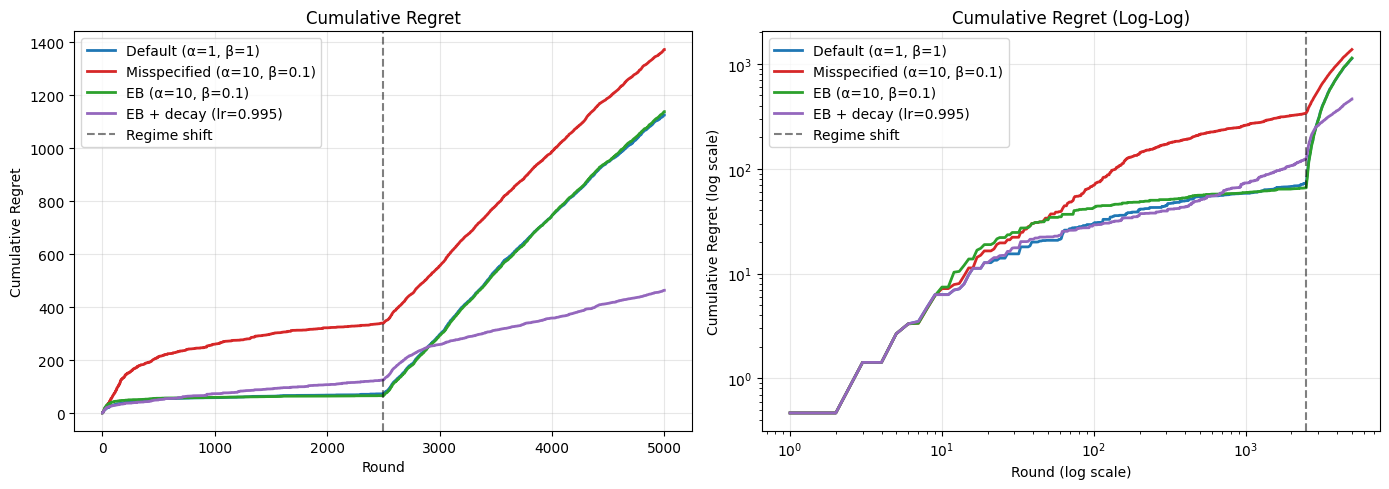

Final cumulative regret:
  Default (α=1, β=1): 1126.2
  Misspecified (α=10, β=0.1): 1373.3
  EB (α=10, β=0.1): 1138.6
  EB + decay (lr=0.995): 463.8


In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    "Default (α=1, β=1)": "C0",
    "Misspecified (α=10, β=0.1)": "C3",
    "EB (α=10, β=0.1)": "C2",
    "EB + decay (lr=0.995)": "C4",
}

for name in agents:
    regret = np.cumsum(optimal_rewards - expected_rewards[name])
    ax1.plot(regret, label=name, linewidth=2, color=colors[name])

ax1.axvline(
    x=SHIFT_ROUND, color="black", linestyle="--", alpha=0.5, label="Regime shift"
)
ax1.set_xlabel("Round")
ax1.set_ylabel("Cumulative Regret")
ax1.set_title("Cumulative Regret")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log-log scale to see sublinear behavior
rounds = np.arange(1, N_ROUNDS + 1)
for name in agents:
    regret = np.cumsum(optimal_rewards - expected_rewards[name])
    ax2.loglog(rounds, regret, label=name, linewidth=2, color=colors[name])

ax2.axvline(
    x=SHIFT_ROUND, color="black", linestyle="--", alpha=0.5, label="Regime shift"
)
ax2.set_xlabel("Round (log scale)")
ax2.set_ylabel("Cumulative Regret (log scale)")
ax2.set_title("Cumulative Regret (Log-Log)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final regret values
print("Final cumulative regret:")
for name in agents:
    regret = np.cumsum(optimal_rewards - expected_rewards[name])[-1]
    print(f"  {name}: {regret:.1f}")

**What to notice:**

- **Before the regime shift** (rounds 0–2499): The stationary EB agent (green) performs best — it quickly corrects its hyperparameters and exploits the strong-signal, low-noise environment. The default agent (blue) does well too. EB + decay (purple) pays a visible regret cost due to its smaller effective sample size. The misspecified agent (red) struggles throughout.

- **After the regime shift** (rounds 2500–4999): The three stationary agents' regret curves steepen — they're pulling the wrong arms with outdated coefficients. The default and EB agents have accumulated so much data from phase 1 that they can't adapt; their learned coefficients are locked in. The **EB + decay agent adapts**: its exponential forgetting discounts the stale phase-1 data, and the EB mechanism re-tunes the hyperparameters to the new regime. Its post-shift regret slope is noticeably lower than the others.

- The **key tradeoff**: decay costs you regret in stationary phases but buys you adaptation when the environment changes. In this experiment, the regime shift is dramatic enough that the adaptation benefit dominates.

## Hyperparameter Evolution

The key advantage of empirical Bayes is visible in how the hyperparameters evolve. Despite starting from badly misspecified values (`alpha=10`, `beta=0.1`), both EB agents quickly adjust them toward values that better reflect the data.

In phase 1, the true noise precision is `beta_true = 1 / 0.5^2 = 4.0`. In phase 2, it drops to `beta_true = 1 / 1.0^2 = 1.0`. We expect the EB + decay agent's `beta` to track this shift, while the stationary EB agent's `beta` remains near its phase-1 value.

The EB + decay agent uses **stabilized forgetting** (Kulhavý & Zarrop, 1993): at each step, a fraction of the EB-tuned prior precision is re-injected into the model, preventing the prior from decaying to zero over time. This ensures that the EB-estimated `alpha` always has a channel to influence the model — and crucially, allows the hyperparameters to adapt when the optimal values change.

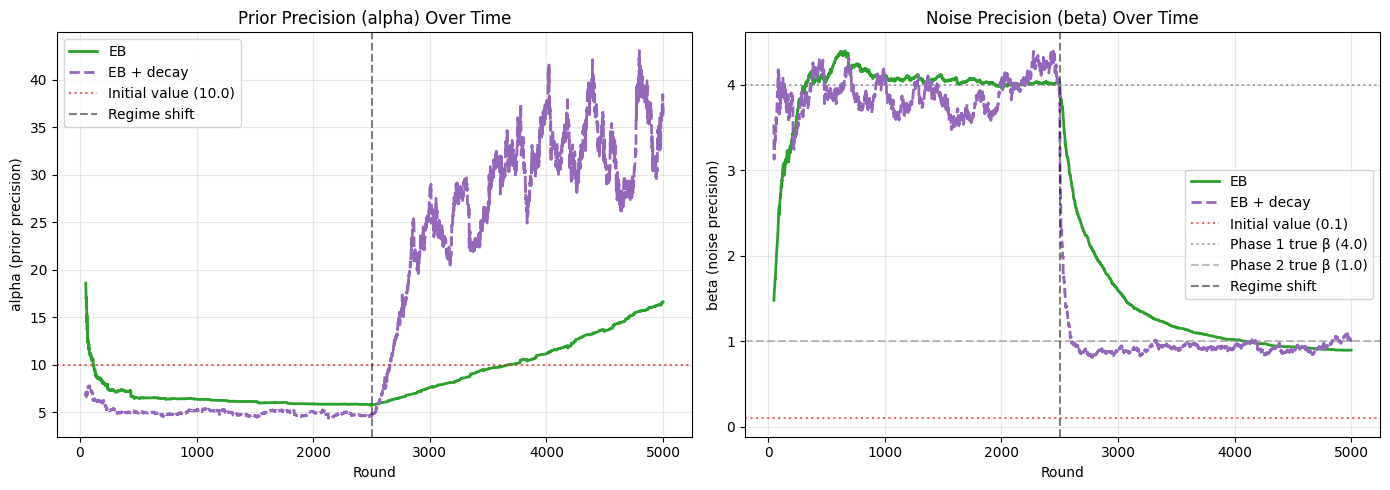

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Skip the first few rounds where alpha is wildly unstable (insufficient data)
SKIP = 50

ax1.plot(
    range(SKIP, N_ROUNDS), eb_alpha_history[SKIP:], linewidth=2, color="C2", label="EB"
)
ax1.plot(
    range(SKIP, N_ROUNDS),
    eb_decay_alpha_history[SKIP:],
    linewidth=2,
    color="C4",
    linestyle="--",
    label="EB + decay",
)
ax1.axhline(y=10.0, color="C3", linestyle=":", alpha=0.7, label="Initial value (10.0)")
ax1.axvline(
    x=SHIFT_ROUND, color="black", linestyle="--", alpha=0.5, label="Regime shift"
)
ax1.set_xlabel("Round")
ax1.set_ylabel("alpha (prior precision)")
ax1.set_title("Prior Precision (alpha) Over Time")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(
    range(SKIP, N_ROUNDS), eb_beta_history[SKIP:], linewidth=2, color="C2", label="EB"
)
ax2.plot(
    range(SKIP, N_ROUNDS),
    eb_decay_beta_history[SKIP:],
    linewidth=2,
    color="C4",
    linestyle="--",
    label="EB + decay",
)
ax2.axhline(y=0.1, color="C3", linestyle=":", alpha=0.7, label="Initial value (0.1)")
# Show true noise precision for both phases
ax2.axhline(
    y=1.0 / TRUE_NOISE_STD_1**2,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label=f"Phase 1 true β ({1.0 / TRUE_NOISE_STD_1**2:.1f})",
)
ax2.axhline(
    y=1.0 / TRUE_NOISE_STD_2**2,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Phase 2 true β ({1.0 / TRUE_NOISE_STD_2**2:.1f})",
)
ax2.axvline(
    x=SHIFT_ROUND, color="black", linestyle="--", alpha=0.5, label="Regime shift"
)
ax2.set_xlabel("Round")
ax2.set_ylabel("beta (noise precision)")
ax2.set_title("Noise Precision (beta) Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What to notice:**

- **Phase 1** (before the dashed line): Both `alpha` traces drop rapidly from 10.0 and both `beta` traces climb from 0.1 toward the true noise precision of 4.0, as in the stationary case.
- **After the regime shift**: The stationary EB agent's (solid green) hyperparameters barely move — 2500 data points of phase-1 evidence anchor its estimates. Its `beta` stays near 4.0 even though the true value is now 1.0.
- The **EB + decay agent** (dashed purple) adapts: its `beta` drops toward the new true value of 1.0, and its `alpha` rises as the weaker phase-2 signal requires more regularization. This is the mechanism behind its lower post-shift regret — the hyperparameters track the new regime because old data has been forgotten.
- The EB + decay traces are noisier throughout, reflecting the smaller effective sample size (~200 observations). This is the cost of adaptability.

## Discussion

### When to use `EmpiricalBayesNormalRegressor`

- **Unknown noise scale**: You don't know how noisy your rewards are (common in most real applications)
- **Unknown signal strength**: You don't know how large the true coefficients are, making it hard to set regularization
- **Sensitivity to hyperparameters**: Your problem is one where bad `alpha`/`beta` values lead to poor performance
- **No offline data for tuning**: You can't cross-validate hyperparameters before deployment

### When plain `NormalRegressor` suffices

- **Well-understood domains**: You have strong prior knowledge about the noise level and coefficient scales
- **Offline tuning available**: You can cross-validate `alpha` and `beta` on historical data before deploying the bandit
- **Computational budget is tight**: EB adds a MacKay update step per `partial_fit` call. For most problems this overhead is negligible, but in extremely latency-sensitive applications it may matter

### Decay and stabilized forgetting

As this notebook demonstrates, decay is not just "insurance" — it is **actively necessary** when the environment is non-stationary. After the regime shift at round 2500:

- The **stationary agents** (including stationary EB) accumulate regret at a steep rate because their learned coefficients and hyperparameters are locked into the phase-1 regime. With 2500 observations already incorporated, new data barely moves the posterior.
- The **EB + decay agent** adapts: exponential forgetting discounts stale phase-1 observations, and the MacKay updates re-tune `alpha` and `beta` to the new noise level and signal strength. The hyperparameter evolution plot shows this clearly — `beta` drops from ~4 toward 1 after the shift.

A naive implementation of decay causes the prior to vanish over time — after enough steps, `gamma^n * alpha ≈ 0`, leaving new or dormant coefficients with no regularization. `EmpiricalBayesNormalRegressor` addresses this with **stabilized forgetting** (Kulhavý & Zarrop, 1993): at each decay step, a fraction `(1 - gamma) * alpha` of the EB-tuned prior precision is re-injected into the precision matrix. This ensures:
- The prior precision converges to `alpha` in steady state (instead of decaying to zero)
- The EB-estimated `alpha` always influences new/dormant coefficients
- Cold-start features receive the current population-level regularization, not a decayed remnant

The tradeoff is visible in phase 1: EB + decay pays a regret cost compared to stationary EB because its effective sample size is smaller (~200 vs 2500). In practice, the right `learning_rate` depends on your expected rate of environmental change — faster change warrants more aggressive decay.

### Key takeaway

The empirical Bayes approach provides **robustness to hyperparameter misspecification** at minimal computational cost. Pairing it with decay and stabilized forgetting adds **robustness to non-stationarity** — the model adapts its hyperparameters and coefficients to track a changing environment, rather than remaining anchored to stale data.